# Recreating the dynbenchmark figures

Python port of [`articles/dynbenchmark.html`](https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html).

In this notebook we reproduce the figures from
[Saelens et al. (2019), *A comparison of single-cell trajectory inference methods*](https://doi.org/10.1038/s41587-019-0071-9). The R vignette uses the bundled `dynbenchmark_data` object; we read the same fixture (exported via `tests/dump_vignette_data.R`) and feed it into `pyfunkyheatmap.funky_heatmap`.

## Load data

The original R object is a list with five members: `data`, `column_info`,
`column_groups`, `row_info`, `row_groups`, and `palettes`. The dump script
writes each one to its canonical Python representation (CSV for tabular
parts, JSON for the palettes list and the per-cell list-columns).

In [1]:
%matplotlib inline
import json
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyfunkyheatmap import funky_heatmap, position_arguments

matplotlib.rcParams['figure.dpi'] = 100

DATA = Path('../data/vignettes')

# main results frame — 51 methods × 159 columns
data = pd.read_csv(DATA / 'dynbenchmark_data.csv')

# decode list-columns: each cell is a JSON dict (named numeric vector in R)
with open(DATA / 'dynbenchmark_data_list_cols.txt') as f:
    list_cols = [line.strip() for line in f if line.strip()]

def _decode(cell):
    if isinstance(cell, float) and np.isnan(cell):
        return {}
    try:
        v = json.loads(cell)
    except (TypeError, json.JSONDecodeError):
        return {}
    return v if isinstance(v, dict) else {}

for col in list_cols:
    if col in data.columns:
        data[col] = data[col].map(_decode)

data.shape

(51, 159)

## Process results

The results table is one big data frame with 159 columns; here is a preview of a handful.

In [2]:
preview_cols = [
    'id',
    'method_source',
    'method_platform',
    'benchmark_overall_norm_correlation',
    'benchmark_overall_norm_featureimp_wcor',
    'benchmark_overall_norm_F1_branches',
    'benchmark_overall_norm_him',
    'benchmark_overall_overall',
]
data[preview_cols].head(8)

,id,method_source,method_platform,benchmark_overall_norm_correlation,benchmark_overall_norm_featureimp_wcor,benchmark_overall_norm_F1_branches,benchmark_overall_norm_him,benchmark_overall_overall
0,paga,tool,Python,0.650494,0.730349,0.608714,0.597455,0.644723
1,raceid_stemid,tool,R,0.539357,0.625525,0.268344,0.453925,0.450245
2,slicer,tool,R,0.138778,0.169503,0.247551,0.553616,0.238283
3,slingshot,tool,R,0.740178,0.724331,0.690913,0.653337,0.701388
4,paga_tree,tool,Python,0.688008,0.736452,0.671616,0.666585,0.690126
5,projected_slingshot,tool,R,0.655131,0.678860,0.682856,0.635703,0.662862
6,mst,offtheshelf,R,0.609871,0.664026,0.576829,0.628801,0.619079
7,monocle_ica,tool,R,0.629028,0.665749,0.596726,0.604896,0.623533


It's possible to use `funky_heatmap` to visualise a subset of the data
frame without providing additional metadata, but it will not have any of
the desired formatting.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


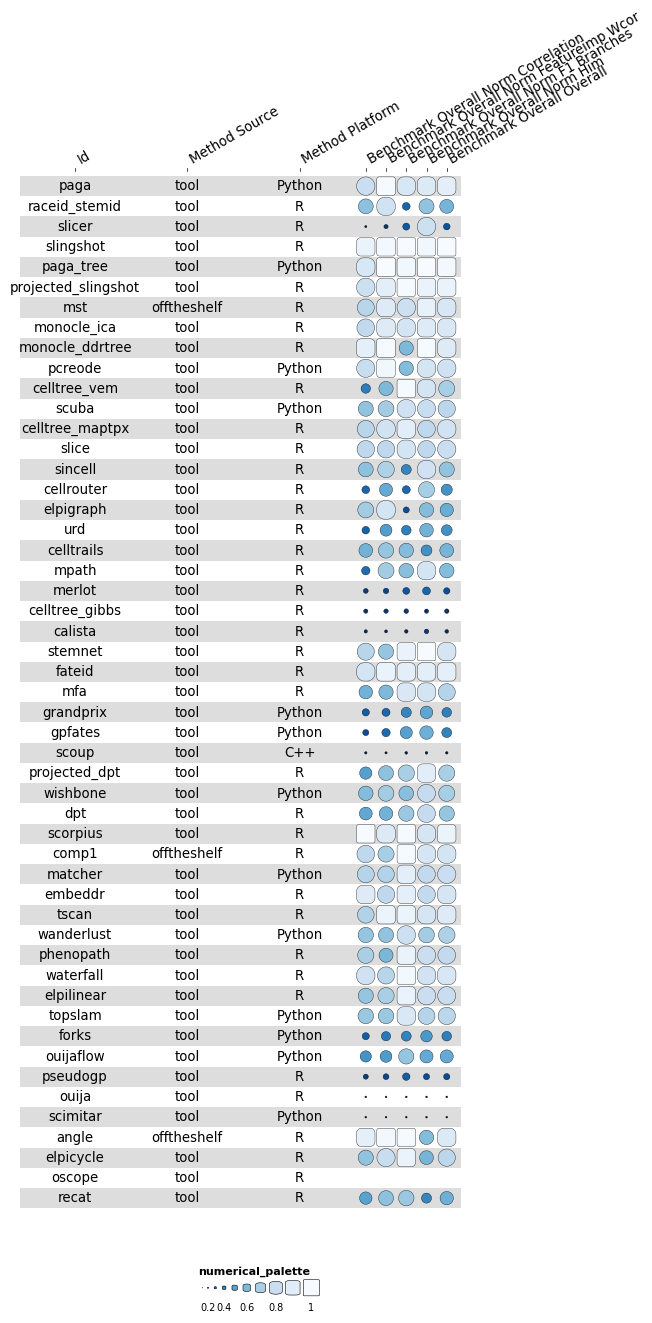

In [3]:
g = funky_heatmap(data[preview_cols], fig_scale=0.2, dpi=100)
g

## Process column info

Apart from the results themselves, the most important additional info is
the column info. This data frame contains information on how each column
should be formatted: which `geom`, which `group`, which `palette`, and a
JSON-encoded `options` dict that spreads into per-column overrides
(`width`, `legend`, `overlay`, …).

In [4]:
column_info = pd.read_csv(DATA / 'dynbenchmark_column_info.csv')
# strip wrapping quotes from any NA-coded strings R may have written
print('column_info shape:', column_info.shape)
column_info.head(10)

column_info shape: (65, 6)


,group,id,name,geom,palette,options
0,method_characteristic,method_name,NaN,text,NaN,"{""hjust"":0,""width"":6}"
1,method_characteristic,method_priors_required_str,Priors required,text,NaN,"{""width"":2}"
2,method_characteristic,method_wrapper_type,Wrapper type,text,NaN,"{""width"":2}"
3,method_characteristic,method_platform,Platform,text,NaN,"{""width"":2}"
4,method_characteristic,method_topology_inference,Topology inference,text,NaN,"{""width"":2}"
5,score_overall,summary_overall_overall,Overall,bar,overall,"{""width"":4,""legend"":false}"
6,score_overall,benchmark_overall_overall,Accuracy,bar,benchmark,"{""width"":4,""legend"":false}"
7,score_overall,scaling_pred_overall_overall,Scalability,bar,scaling,"{""width"":4,""legend"":false}"
8,score_overall,stability_overall_overall,Stability,bar,stability,"{""width"":4,""legend"":false}"
9,score_overall,qc_overall_overall,Usability,bar,qc,"{""width"":4,""legend"":false}"


With just the data and the column info, we can already get a pretty good
funky heatmap. We restrict to the columns that actually appear in
`column_info` so unused 100+ columns don't have to be re-validated.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


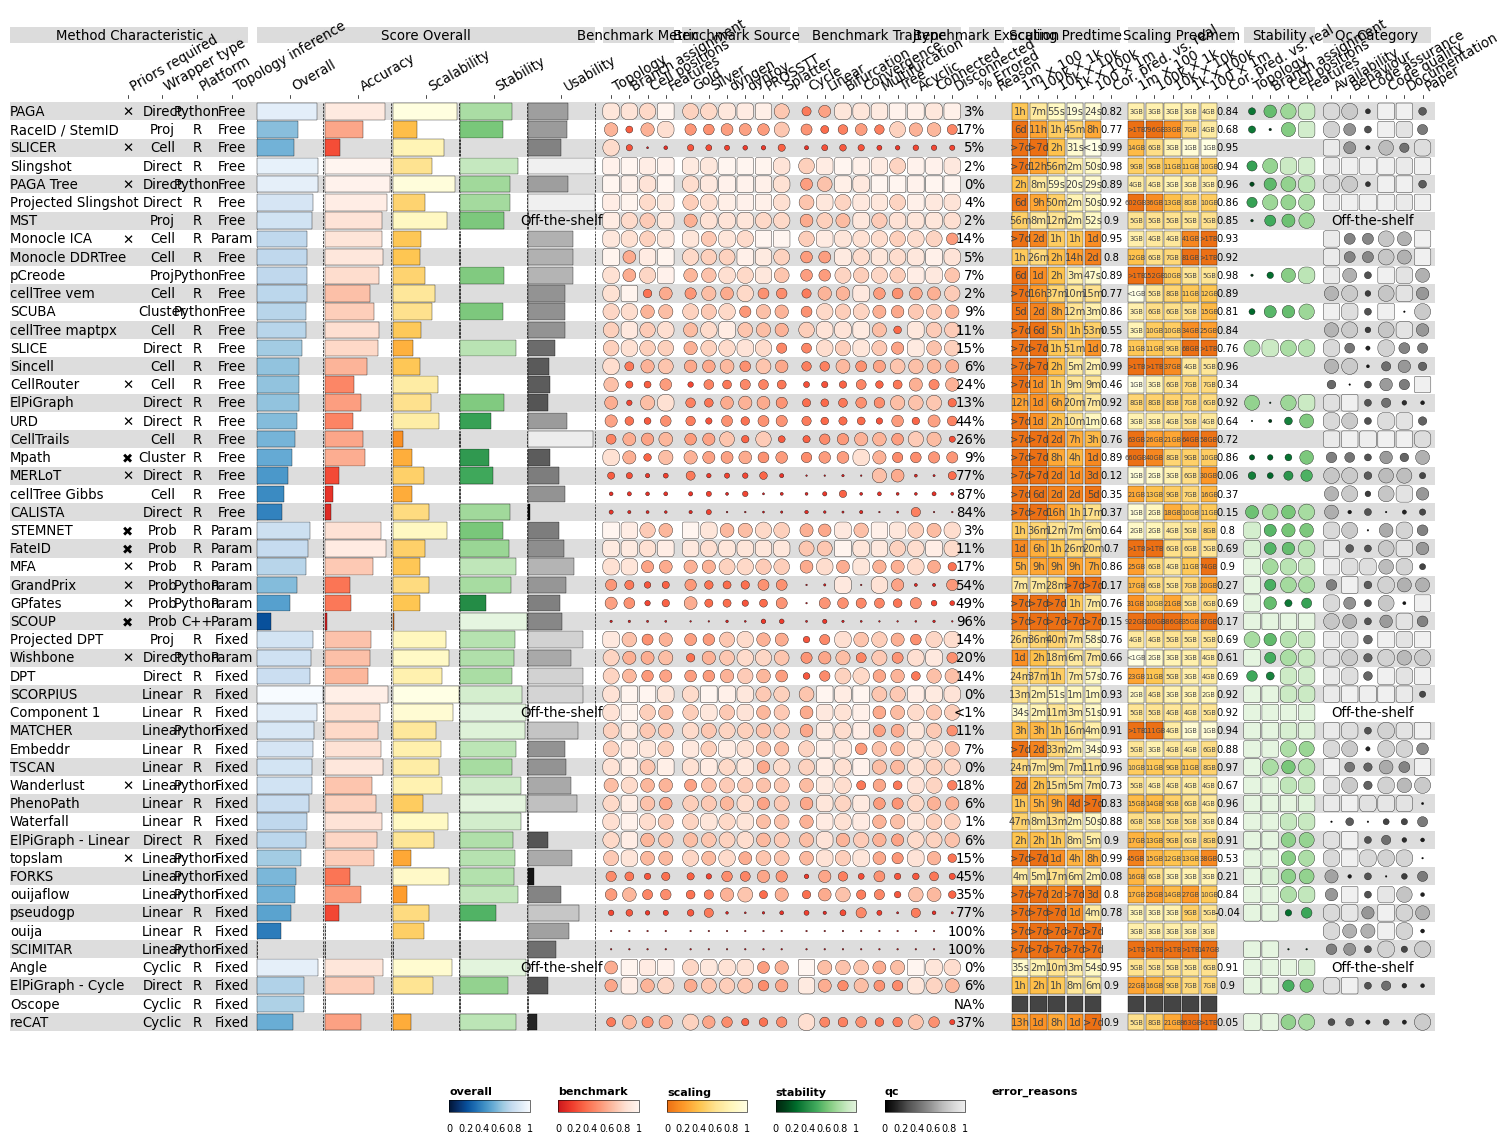

In [5]:
g = funky_heatmap(
    data,
    column_info=column_info,
    fig_scale=0.18,
    dpi=100,
)
g

## Finetuning the visualisation

The figure can be fine-tuned by grouping the columns and rows and specifying custom palettes.

### Column groups

In [6]:
column_groups = pd.read_csv(DATA / 'dynbenchmark_column_groups.csv')
column_groups

,Experiment,Category,group,palette
0,Method,\n,method_characteristic,overall
1,Summary,Aggregated scores per experiment,score_overall,overall
2,Accuracy,Per metric,benchmark_metric,benchmark
3,Accuracy,Per dataset source,benchmark_source,benchmark
4,Accuracy,Per trajectory type,benchmark_trajtype,benchmark
5,Accuracy,Errors,benchmark_execution,benchmark
6,Scalability,Predicted time\n(#cells × #features),scaling_predtime,scaling
7,Scalability,Predicted memory\n(#cells × #features),scaling_predmem,scaling
8,Stability,Similarity\nbetween runs,stability,stability
9,Usability,Quality of\nsoftware and paper,qc_category,qc


### Row info

In [7]:
row_info = pd.read_csv(DATA / 'dynbenchmark_row_info.csv')
row_info.head(8)

,group,id
0,graph,paga
1,graph,raceid_stemid
2,graph,slicer
3,tree,slingshot
4,tree,paga_tree
5,tree,projected_slingshot
6,tree,mst
7,tree,monocle_ica


### Row grouping

In [8]:
row_groups = pd.read_csv(DATA / 'dynbenchmark_row_groups.csv')
row_groups

,group,Group
0,graph,Graph methods
1,tree,Tree methods
2,multifurcation,Multifurcation methods
3,bifurcation,Bifurcation methods
4,linear,Linear methods
5,cycle,Cyclic methods


### Palettes

In [9]:
with open(DATA / 'dynbenchmark_palettes.json') as f:
    palettes_raw = json.load(f)
# R serialises this as [{palette: name, colours: <list-or-dict>}, ...].
# A dict colours field encodes a *named* R palette (category -> hex); a list
# encodes an unnamed sequential ramp. Both are kept as-is for Python.
palettes = {entry['palette']: entry['colours'] for entry in palettes_raw}
list(palettes.keys())

['overall',
 'benchmark',
 'scaling',
 'stability',
 'qc',
 'error_reasons',
 'white6black4']

## Generate funky heatmap

The resulting visualisation contains all of the results by
[Saelens et al. (2019)](https://doi.org/10.1038/s41587-019-0071-9) in a single plot.

> Note that Figures 2 and 3 from the main paper and Supplementary Figure 2 were generated by making different subsets of the `column_info` and `column_groups` objects.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


saved dynbenchmark_py.png; w= 15.9 h= 13.0


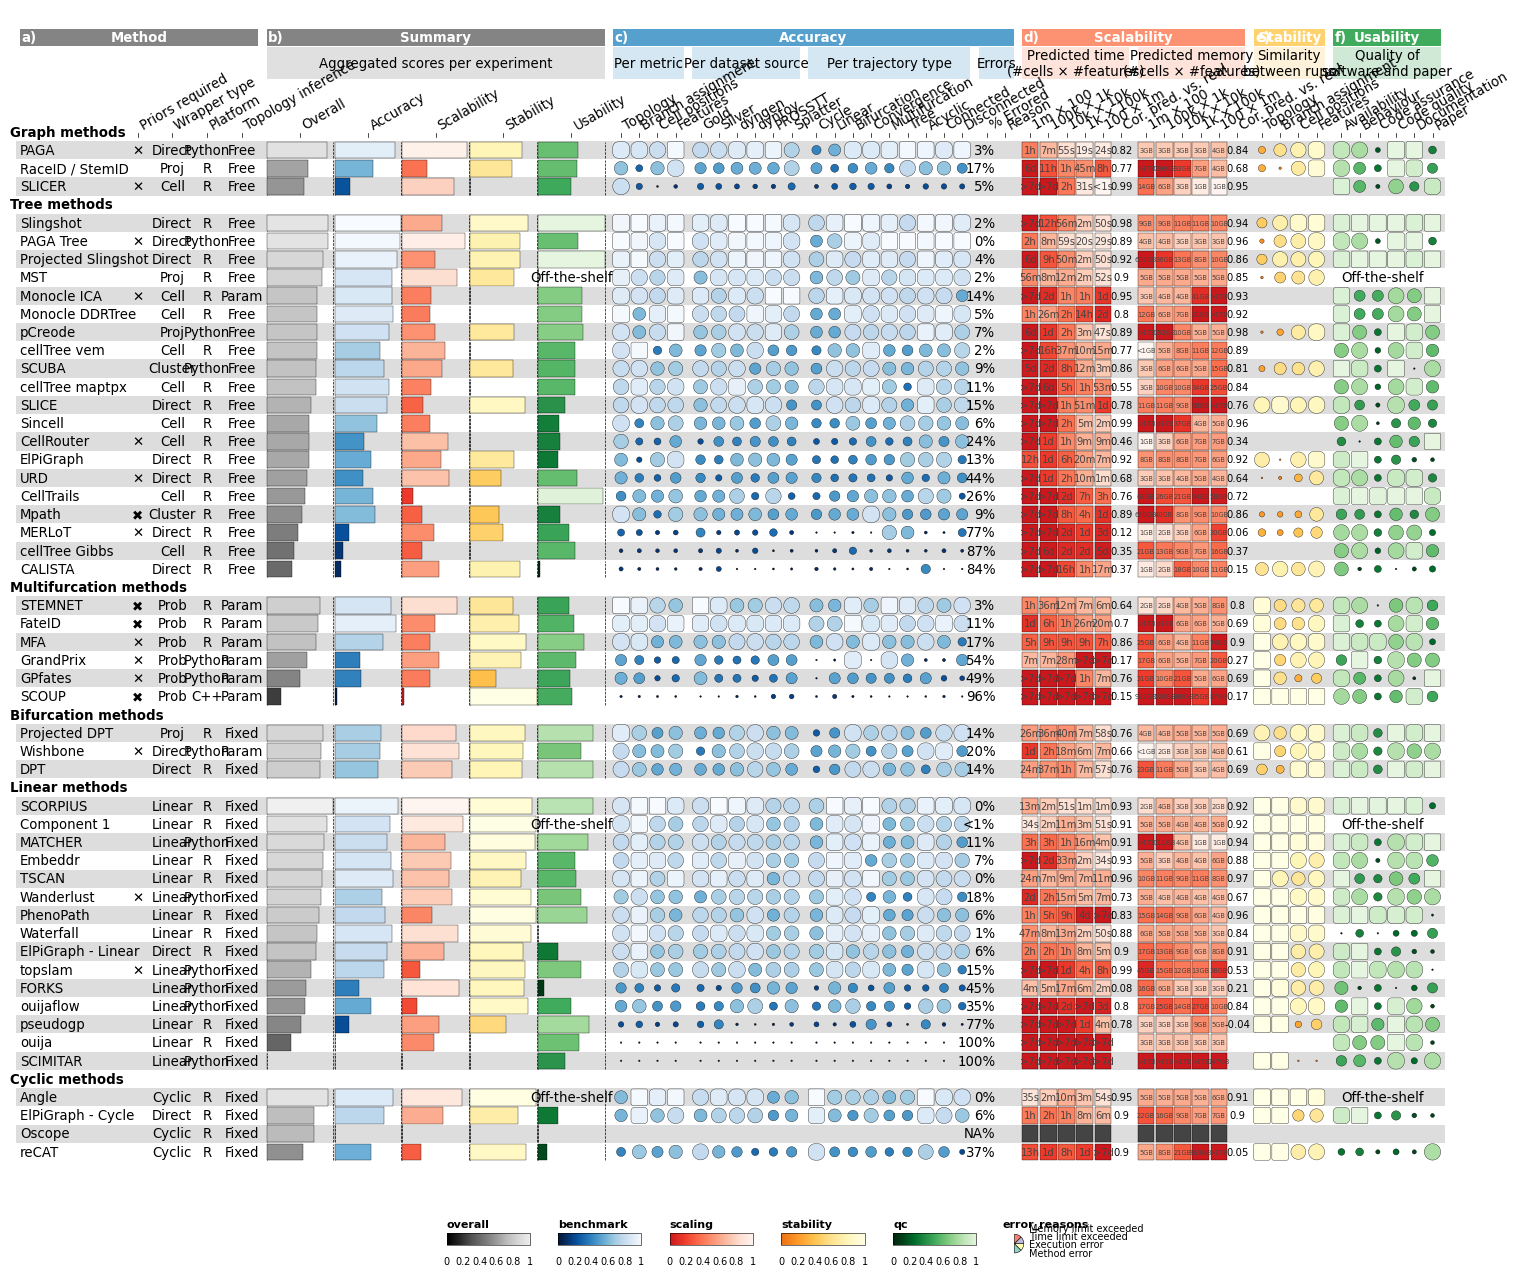

In [10]:
g = funky_heatmap(
    data=data,
    column_info=column_info,
    column_groups=column_groups,
    row_info=row_info,
    row_groups=row_groups,
    palettes=palettes,
    position_args=position_arguments(col_annot_offset=3.2),
    fig_scale=0.18,
    dpi=100,
)
g.save('../data/vignettes/dynbenchmark_py.png', dpi=130, facecolor='white')
print('saved dynbenchmark_py.png; w=', round(g.width,1), 'h=', round(g.height,1))
g

`funkyheatmap` automatically recommends a width and height for the
generated plot. To save the plot at the suggested dimensions:

```python
g.save('dynbenchmark.pdf', dpi=200)
```

### Side-by-side with the R reference

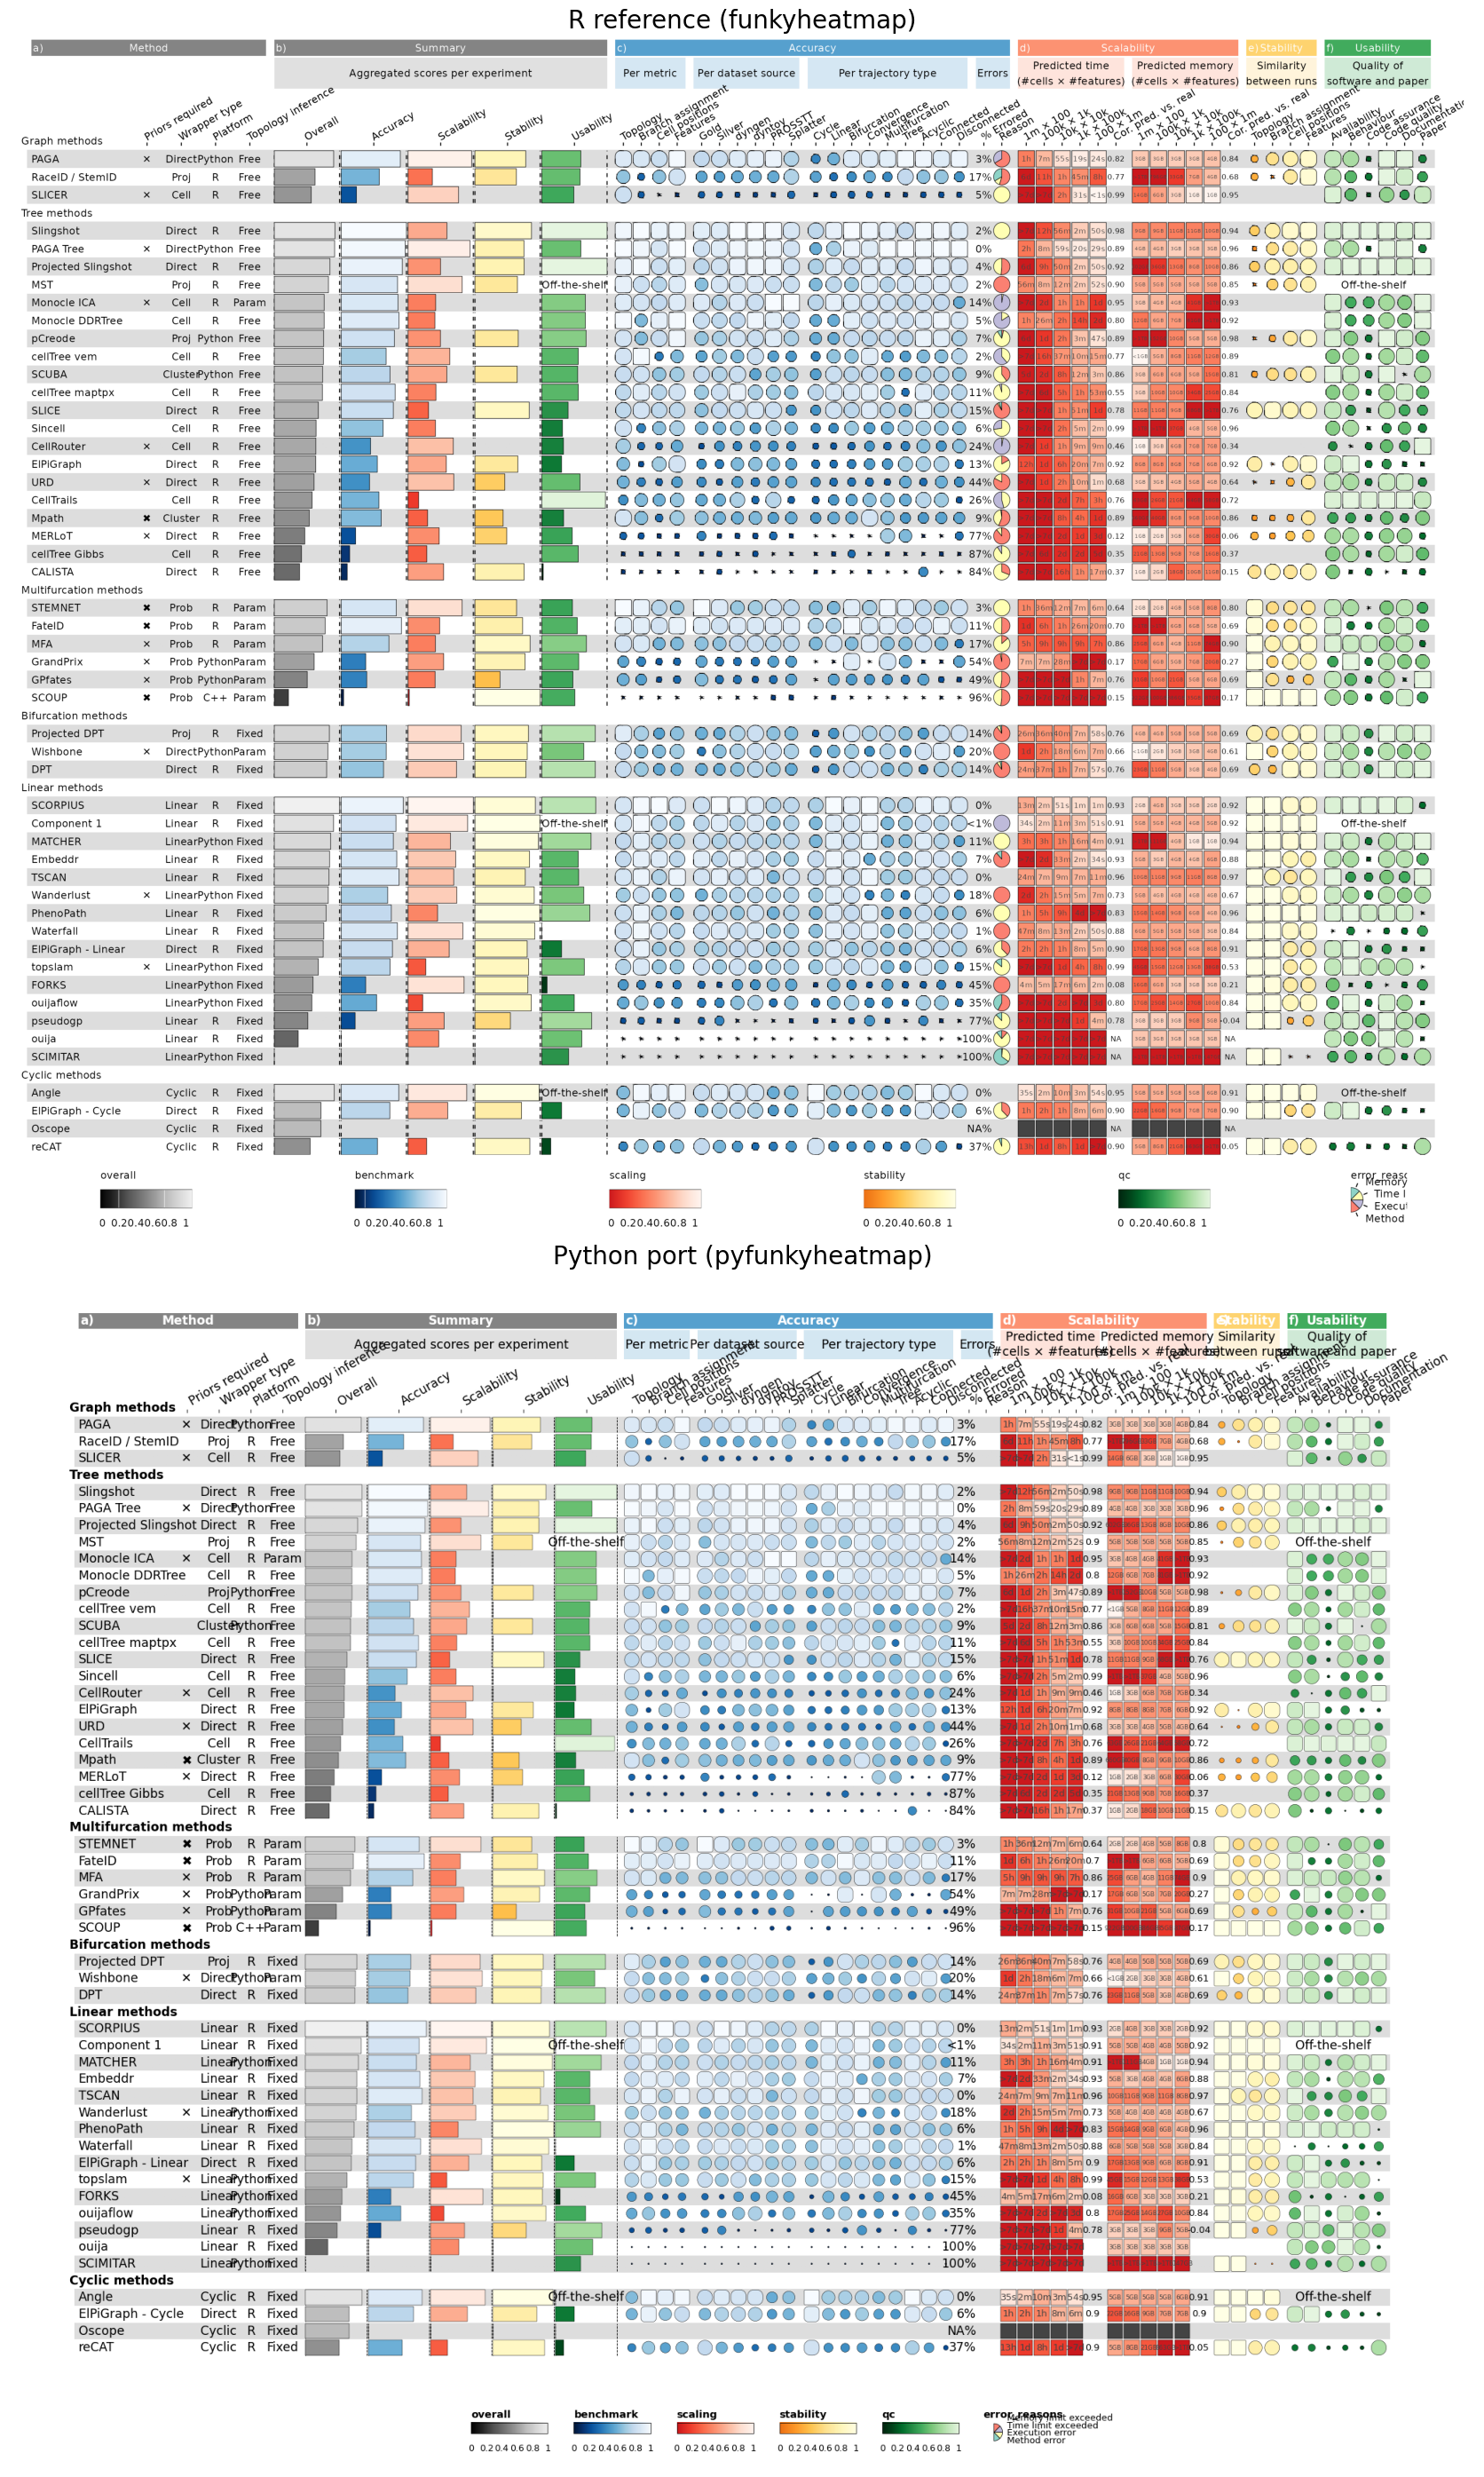

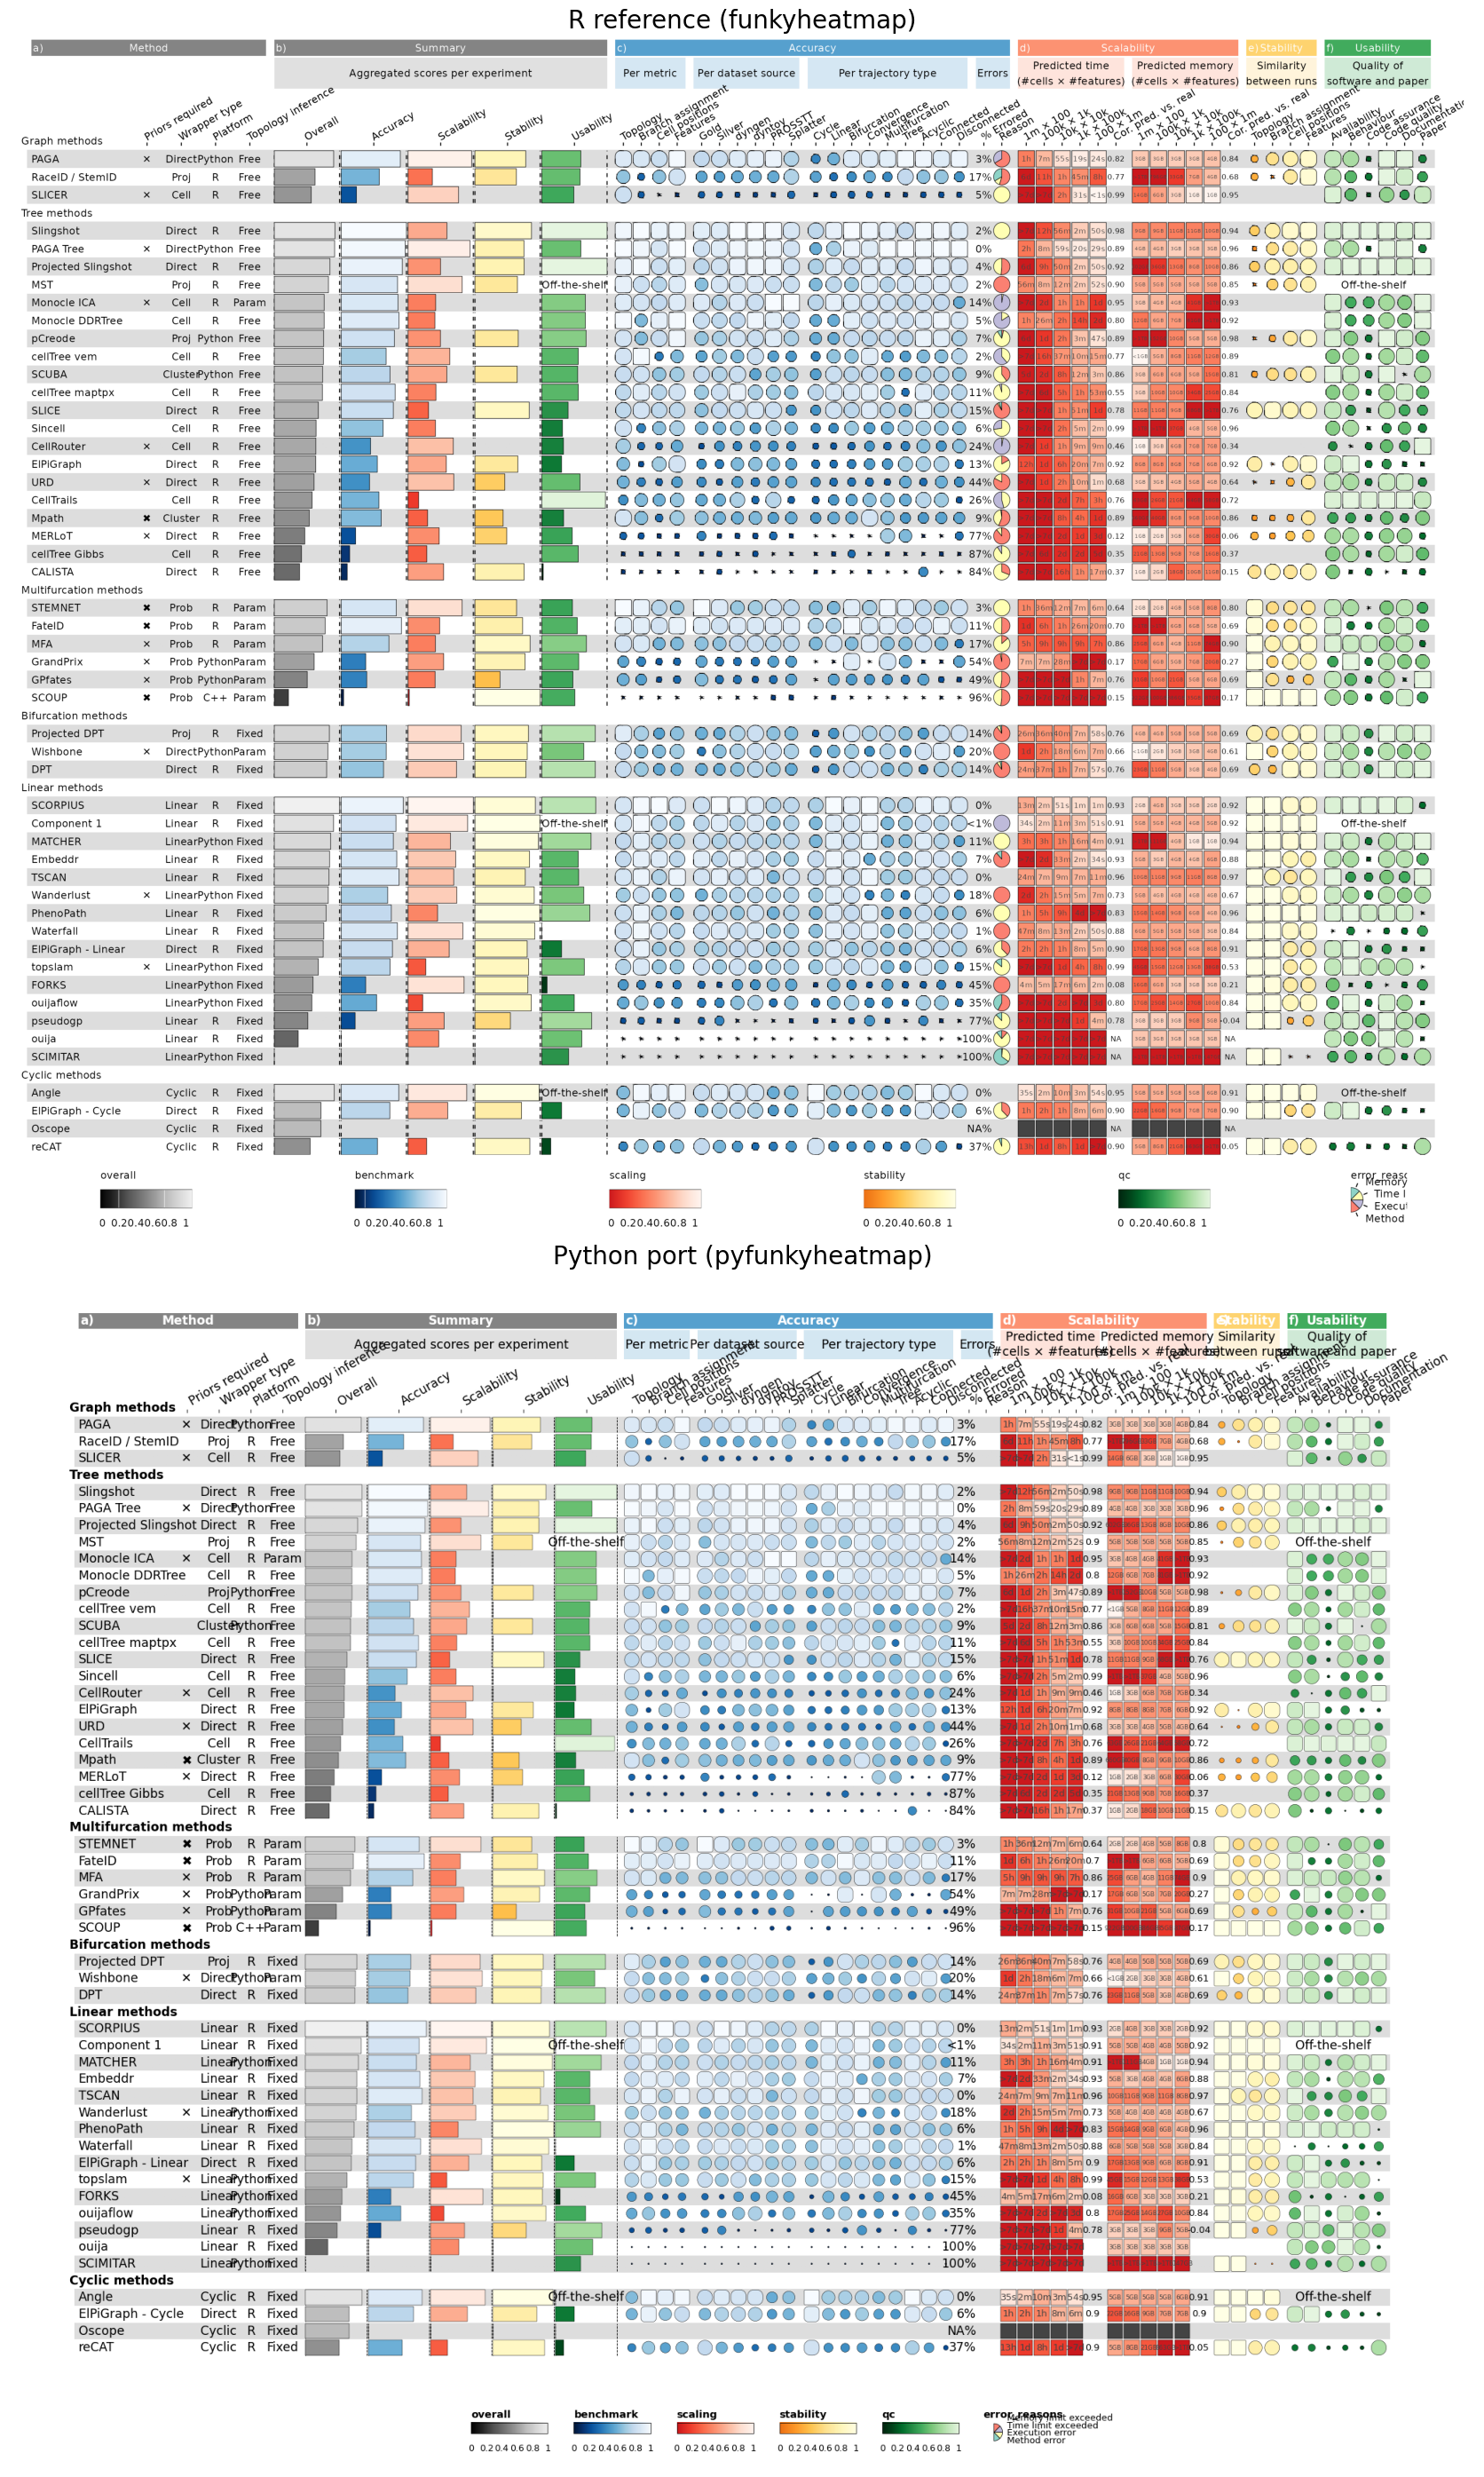

In [11]:
import matplotlib.image as mpimg
fig, axes = plt.subplots(2, 1, figsize=(22, 28))
axes[0].imshow(mpimg.imread('../data/vignettes/dynbenchmark_R.png'));   axes[0].set_title('R reference (funkyheatmap)',  fontsize=20); axes[0].axis('off')
axes[1].imshow(mpimg.imread('../data/vignettes/dynbenchmark_py.png'));  axes[1].set_title('Python port (pyfunkyheatmap)', fontsize=20); axes[1].axis('off')
plt.tight_layout()
fig

## References

* Saelens, W., Cannoodt, R., Todorov, H. *et al.* **A comparison of single-cell trajectory inference methods.** *Nat Biotechnol* 37, 547–554 (2019). https://doi.org/10.1038/s41587-019-0071-9
* [`dynverse/dynbenchmark_results`](https://github.com/dynverse/dynbenchmark_results) — upstream raw results.